# Пошуковий аналіз даних

<h2>Мета</h2>

Ознайомитись з методами перевірки статистичних гіпотез. Після завершення цієї лабораторної роботи ви зможете:

* Досліджувати дані за допомогою візуалізацій
* Робити описовий аналіз
* Групувати дані для аналізу
* Знаходити зв'язок між ознаками
* Перевіряти гіпотези про значущість коефіцієнта кореляції та про вигляд закону розподілу
* Робити дисперсійний аналіз



<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>


1. Скачати дані із файлу, який зберегли наприкінці попередньої роботи (з виправленими помилками та заповненими пропусками). Записати дані у dataframe. Дослідити ознаки з метою виявлення звязку між ними, побудувавши їх візуалізації. Візуально оцініть наявність та силу зв'язку між ознаками.
2. Порахувати кореляцію між всіма кількісними ознаками
3. Побудувати діаграми розсіювання для кількісних ознак та 'CO2 emission'. Які кількісні ознаки можуть бути предикторами кількості викидів СО2?
4. Побудувати діаграму розмаху для 'CO2 emission' по регіонам.
5. Виконати дисперсійний аналіз для кількості викидів СО2, згрупувати дані по регіонам

<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Дослідити ознаки з метою виявлення зв'язку між ними, побудувавши їх візуалізації</p>
</div>


In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Зчитую дані з файлу у датафрейм

In [4]:
PATH = 'clean_data2.csv'
df = pd.read_csv(PATH, sep=",", encoding='utf-8')
df.drop('Unnamed: 0', axis=1, inplace=True)
df.head()

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Population Density
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225,652860.0,53.083405
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853,28750.0,100.038296
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217,2381740.0,17.048902
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,6501.591,200.0,277.995000
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042,470.0,164.427660


In [4]:
# Виводимо типи даних для кожної колонки, щоб зрозуміти, які типи даних містяться в нашому наборі даних
print(df.dtypes)

# Кількістні змінні
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
# Категоріальні змінні
categorical_cols = df.select_dtypes(include=['object']).columns

Country Name           object
Region                 object
GDP per capita        float64
Population            float64
CO2 emission          float64
Area                  float64
Population Density    float64
dtype: object


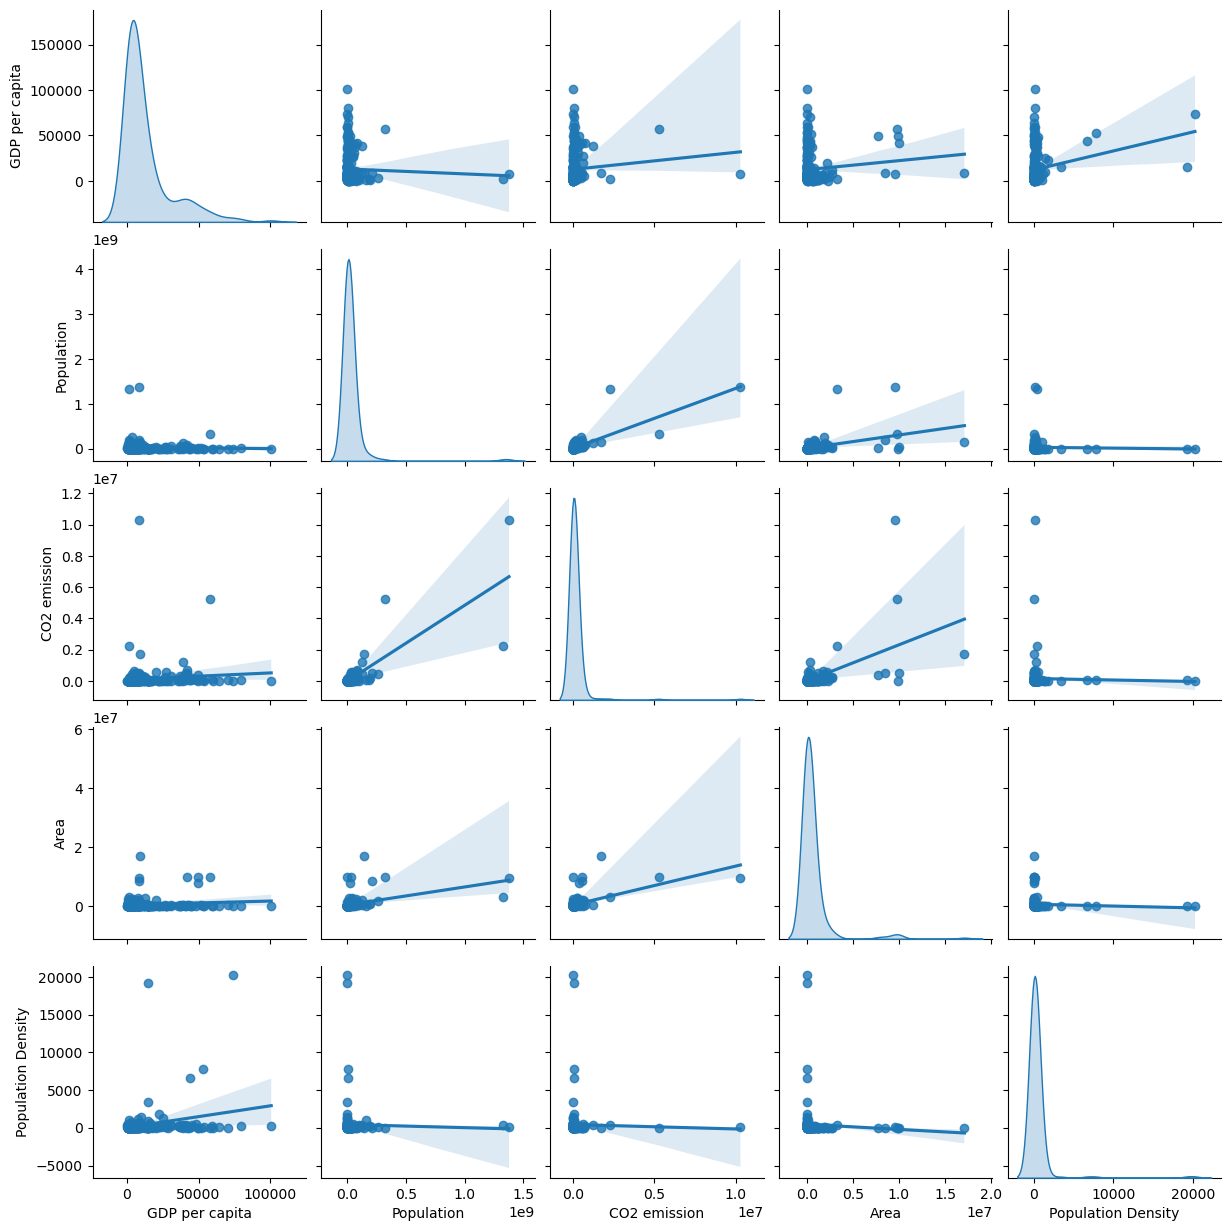

In [5]:
# Побудуємо графік для кількісних змінних, щоб побачити їх розподіл
sns.pairplot(df[numerical_cols], kind='reg', diag_kind='kde')

Візуально оцінінюю наявність та силу зв'язку між  ознаками.

<a name="task2"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2">Завдання  #2: </h2>

<p>Порахувати кореляцію між всіма кількісними ознаками</p>
</div>


Рахую кореляцію між всіма кількісними ознаками

Text(0.5, 1.0, 'Correlation Matrix')

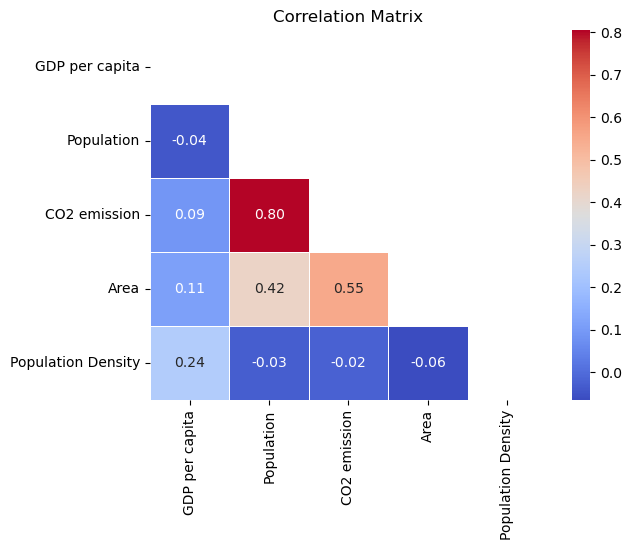

In [6]:
df_corr = df[numerical_cols].corr()
mask = np.triu(np.ones_like(df_corr, dtype=bool))

sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, mask=mask)
plt.title("Correlation Matrix")

<a name="task3"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3">Завдання  #3: </h2>

<p>Побудувати діаграми розсіювання для кількісних ознак та 'CO2 emission'. Візуально оцінити наявність та силу зв'язку між цими ознаками.</p>
</div>


Будую діаграму розсіювання для кількісних ознак та 'CO2 emission'

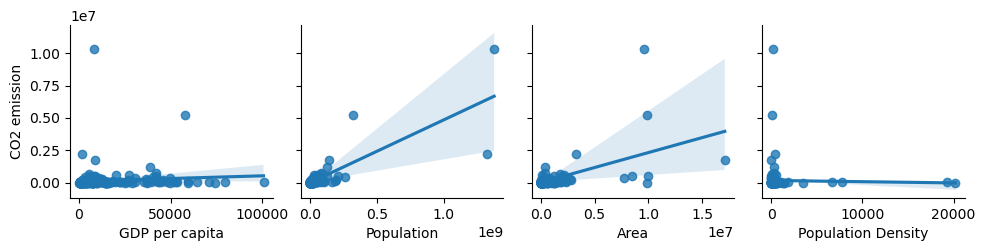

In [7]:
df_numerical = df[numerical_cols]
sns.pairplot(df_numerical, x_vars=df_numerical.drop(columns=['CO2 emission']).columns, 
             y_vars=['CO2 emission'], kind='reg')

<p>Які кількісні ознаки можуть бути предикторами кількості викидів СО2? </p> 
<p> Обчислюю коефіцієнт кореляції Пірсона та P-value для всіх кількісних змінних та 'CO2 emission'</p> 

In [8]:
# Обчислення коефіцієнта кореляції Пірсона та P-value для всіх кількісних змінних та 'CO2 emission'
from scipy.stats import pearsonr

for col in numerical_cols:
    if col != 'CO2 emission':
        corr, p_value = pearsonr(df[col], df['CO2 emission'])
        print(f"Correlation between {col} and CO2 emission: {corr}, P-value: {p_value}")


Correlation between GDP per capita and CO2 emission: 0.08842604358460804, P-value: 0.1944190076007917
Correlation between Population and CO2 emission: 0.8040913776439701, P-value: 1.8722847901371025e-50
Correlation between Area and CO2 emission: 0.5516969339934816, P-value: 1.1085501804133189e-18
Correlation between Population Density and CO2 emission: -0.02355808148433695, P-value: 0.7300374170520622


Кількісні ознаки, які можуть бути предикторами кількості викидів СО2:
1. Кореляція між ВВП на душу населення та викидами CO2 є дуже слабкою (r = 0.088) і статистично незначущою (p = 0.194), що свідчить про відсутність суттєвого зв’язку між рівнем доходу та викидами;
2. Кореляція між населенням і викидами CO2 є сильною (r = 0.804) та статистично значущою (p < 0.001), що означає, що країни з більшим населенням мають значно вищі викиди CO2;
3. Кореляція між площею країни та викидами CO2 є помірною (r = 0.552) і статистично значущою (p < 0.001), що вказує на те, що більші країни зазвичай мають більші обсяги викидів;
4. Кореляція між щільністю населення та викидами CO2 є практично відсутньою (r = -0.024) і статистично незначущою (p = 0.730), що свідчить про відсутність зв’язку.

<a name="task4"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4">Завдання  #4: </h2>

<p>Побудувати діаграму розмаху для 'CO2 emission' по регіонам. </p>
</div>


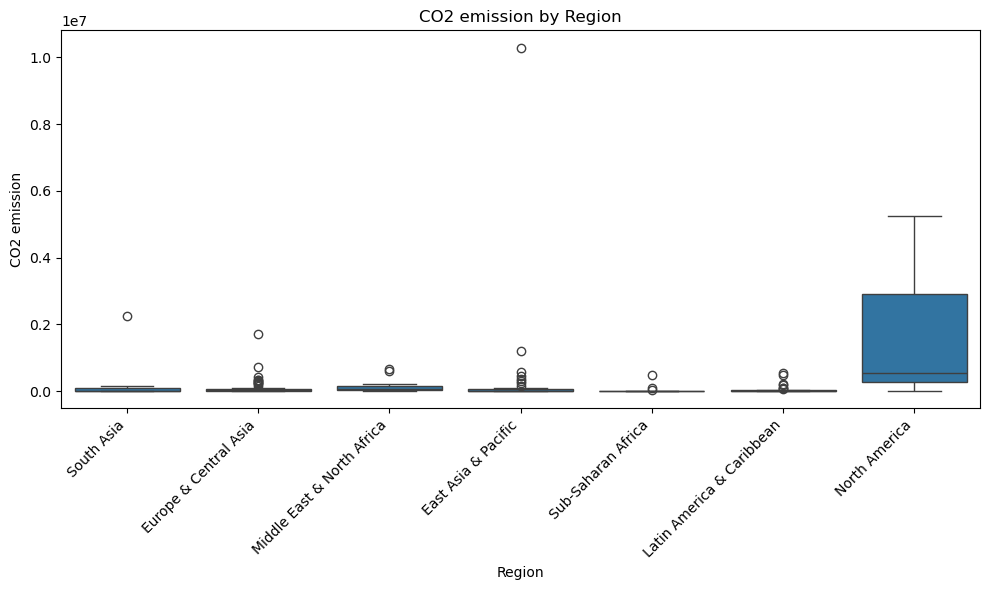

In [175]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Region', y='CO2 emission')
plt.title("CO2 emission by Region")
plt.xlabel("Region")
plt.ylabel("CO2 emission")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<a name="task5"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5">Завдання  #5: </h2>

<p>Виконати дисперсійний аналіз для кількості викидів СО2, згрупувати дані по регіонам</p>
</div>


Групую дані, щоб побачити чи впливає 'Region' на 'CO2 emission'.

In [184]:
grouped_data = df[['Region', 'CO2 emission']].groupby('Region')

Перевіряю розподіл даних в групах, щоб обрати вид дисперсійного аналізу.

In [186]:
import scipy.stats as stats

# Перевірка нормальності розподілу CO2 emission для кожного регіону за допомогою тесту Шапіро-Уілка,
# якщо не нормальний розподіл, то можна використовувати непараметричні тести для подальшого аналізу

results = []
for region, group in grouped_data:
    data = group['CO2 emission']
    stat, p_value = stats.shapiro(data) 
    results.append((region, len(data), stat, p_value))

df_list = pd.DataFrame(results, columns=['Region', 'n', 'statistic', 'p_value'])
df_list["normal"] = df_list["p_value"] > 0.05
df_list

,Region,n,statistic,p_value,normal
0,East Asia & Pacific,37,0.224239,9.302523e-13,False
1,Europe & Central Asia,58,0.432444,1.252764e-13,False
2,Latin America & Caribbean,42,0.441260,1.899448e-11,False
3,Middle East & North Africa,21,0.641445,5.577124e-06,False
4,North America,3,0.825726,1.775188e-01,True
5,South Asia,8,0.472738,4.837927e-06,False
6,Sub-Saharan Africa,48,0.215243,1.385671e-14,False


<p style="font-style: italic;"> За результатами перевірки нормальності розподілу за критерієм Шапіро-Уілка бачимо, що у більшості регіонів (6 із 7) розподіл показника викидів CO2 відрізняється від нормального. Отже, припущення нормальності не виконується, тому для подальшого аналізу доцільно використовувати непараметричний критерій Краскела-Уолліса. </p>

Для отримання F-test score та P-value скористаюсь функцією <code>f_oneway</code> з модуля "stats" , якщо розподіл даних в групах дозволяє застосувати класичний дисперсійний аналіз, або <code>kruskal</code> з модуля "stats" для непараметричного дисперсійного аналізу Краскела-Уоліса.

In [187]:
groups = [group['CO2 emission'].values for _, group in grouped_data]
stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-statistic: {stat:.2f}, P-value: {p_value:.7f}")

Kruskal-Wallis H-statistic: 44.69, P-value: 0.0000001


Результати критерію Краскела-Уолліса (H = 44.69, p < 0.001) показують, що між досліджуваними регіонами існують статистично значущі відмінності у рівнях викидів CO2. Але чи означає це, що досліджувані групи значуще відрізняються між собою? Розглянемо їх окремо.

In [188]:
import scikit_posthocs as sp
dunn_results = sp.posthoc_dunn( grouped_data.obj, val_col='CO2 emission', group_col='Region', p_adjust='bonferroni')
dunn_results

,East Asia & Pacific,Europe & Central Asia,Latin America & Caribbean,Middle East & North Africa,North America,South Asia,Sub-Saharan Africa
East Asia & Pacific,1.000000,0.079465,1.000000,0.015848,1.00000,1.000000,1.000000
Europe & Central Asia,0.079465,1.000000,0.008372,1.000000,1.00000,1.000000,0.000006
Latin America & Caribbean,1.000000,0.008372,1.000000,0.002493,1.00000,1.000000,1.000000
Middle East & North Africa,0.015848,1.000000,0.002493,1.000000,1.00000,1.000000,0.000011
North America,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,0.713890
South Asia,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,0.557844
Sub-Saharan Africa,1.000000,0.000006,1.000000,0.000011,0.71389,0.557844,1.000000


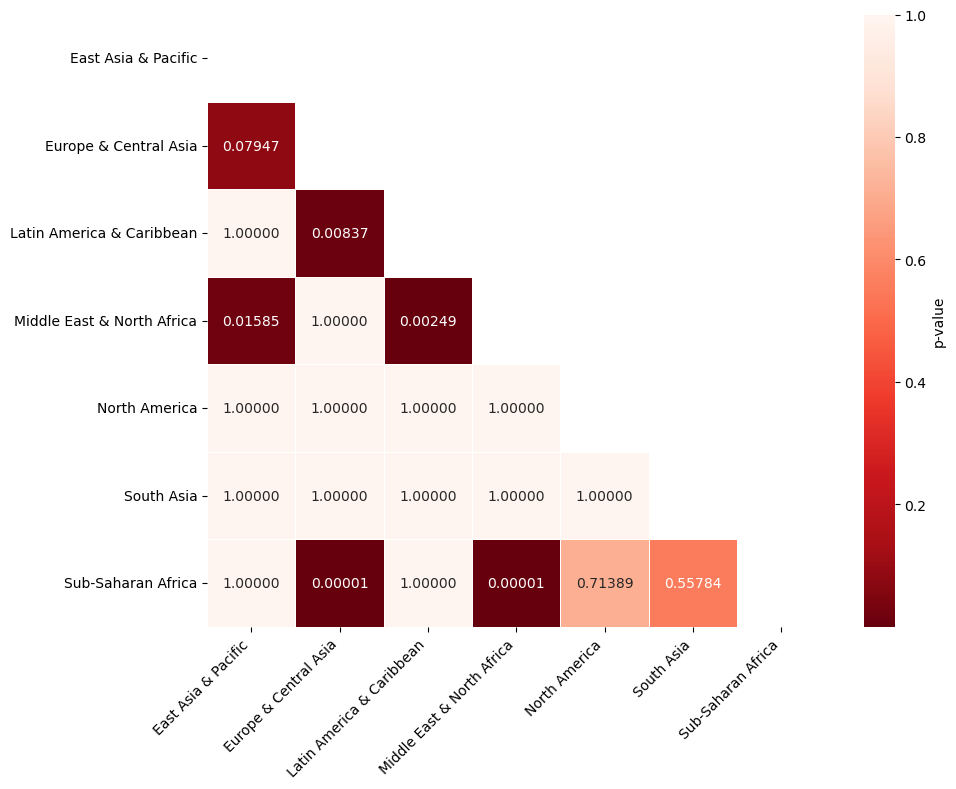

In [189]:
mask = np.triu(np.ones_like(dunn_results, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(dunn_results, annot=True, cmap='Reds_r', fmt=".5f", linewidths=0.5, mask=mask, cbar_kws={'label': 'p-value'})
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


## Висновок:
<p style="font-family: Arial, sans-serif; font-size: 20px;"> У результаті застосування критерію Краскела-Уолліса було встановлено, що між регіонами існують статистично значущі відмінності у рівнях викидів CO2. Це свідчить про те, що принаймні одна з груп відрізняється від інших. Для детального аналізу було використано тест Данна з поправкою. Результати показали, що статистично значущі відмінності спостерігаються між такими парами регіонів: (Europe & Central Asia та Sub-Saharan Africa), (Middle East & North Africa та Sub-Saharan Africa), а також (Europe & Central Asia та Latin America & Caribbean) і (Latin America & Caribbean та Middle East & North Africa). Також виявлено відмінність між East Asia & Pacific та Middle East & North Africa. Водночас між більшістю інших пар регіонів статистично значущих відмінностей не виявлено.</p>

<a name="task6"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Дайте відповіді на питання</p>
</div>


1. По результатам дисперсійного аналізу для кількості викидів СО2 по регіонам, вкажіть пару регіонів, що відрізняються найсильніше.
2. Створіть якісну ознаку 'Rich country', згрупувавши дані 'GDP per capita' в кілька категорій (багаті-бідні країни, 3-5 категорій). Побудуйте діаграму розмаху для 'CO2 emission' по категоріям 'Rich country'. Візуально оцініть наявність зв'язку між цими ознаками.
3. Виконайте дисперсійний аналіз для 'CO2 emission', згрупувавши дані по категоріям 'Rich country'.

<details><summary>Натисніть тут, щоб побачити підказку</summary>

Групування кількісної змінної в категорії було в попередній лабораторній роботі. Використайте функцію "cut"
</details>

In [158]:
stacked  = dunn_results.mask(mask).stack()
print("Найсильніша різниця між:", stacked.idxmin())
print("p-value:", stacked.min())

Найсильніша різниця між: ('Sub-Saharan Africa', 'Europe & Central Asia')
p-value: 5.782984396269479e-06


In [159]:
df['Rich country'] = df['Rich country'] = pd.qcut(df['GDP per capita'], q=4,labels=['Low', 'Lower-middle', 'Upper-middle', 'High'])

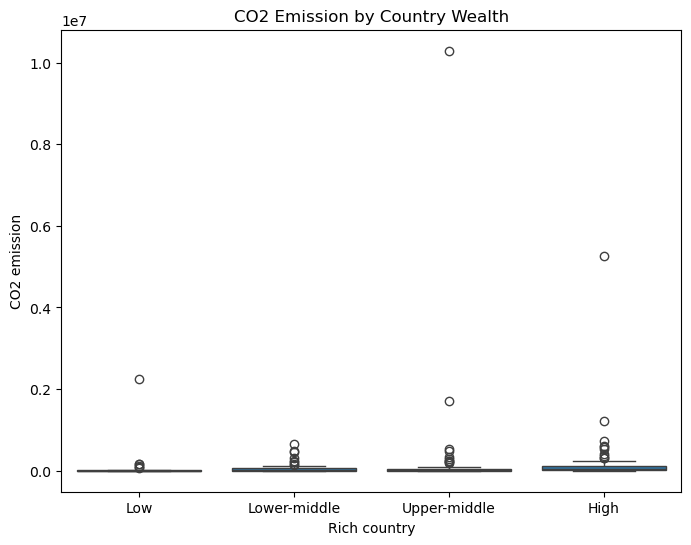

In [160]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Rich country', y='CO2 emission')
plt.title("CO2 Emission by Country Wealth")
plt.show()

In [181]:
# Перевіричо чи нормально розподілені дані для кожної категорії багатства країни
grouped_wealth = df[['Rich country', 'CO2 emission']].groupby('Rich country', observed=False)

results = []
for rich_country, group in grouped_wealth:
    data = group['CO2 emission']
    stat, p_value = stats.shapiro(data) 
    results.append((rich_country, len(data), stat, p_value))

df_list = pd.DataFrame(results, columns=['Rich country', 'n', 'statistic', 'p_value'])
df_list["normal"] = df_list["p_value"] > 0.05
df_list

,Rich country,n,statistic,p_value,normal
0,Low,55,0.168332,5.087697e-16,False
1,Lower-middle,54,0.545140,1.099486e-11,False
2,Upper-middle,55,0.186560,7.484587e-16,False
3,High,53,0.298227,1.713636e-14,False


In [162]:
# Оскільки дані не є нормально розподіленими, використаємо непараметричний тест 
# Краскела-Уолліса для порівняння рівнів викидів CO2 між різними категоріями багатства країни
groups = [group['CO2 emission'].values for _, group in grouped_wealth]
stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-statistic: {stat:.2f}, P-value: {p_value:.7f}")

Kruskal-Wallis H-statistic: 23.56, P-value: 0.0000309


In [163]:
dunn_results = sp.posthoc_dunn(grouped_wealth.obj, val_col='CO2 emission', group_col='Rich country', p_adjust='bonferroni')
dunn_results

,Low,Lower-middle,Upper-middle,High
Low,1.000000,0.112019,0.399509,0.000009
Lower-middle,0.112019,1.000000,1.000000,0.084203
Upper-middle,0.399509,1.000000,1.000000,0.016680
High,0.000009,0.084203,0.016680,1.000000


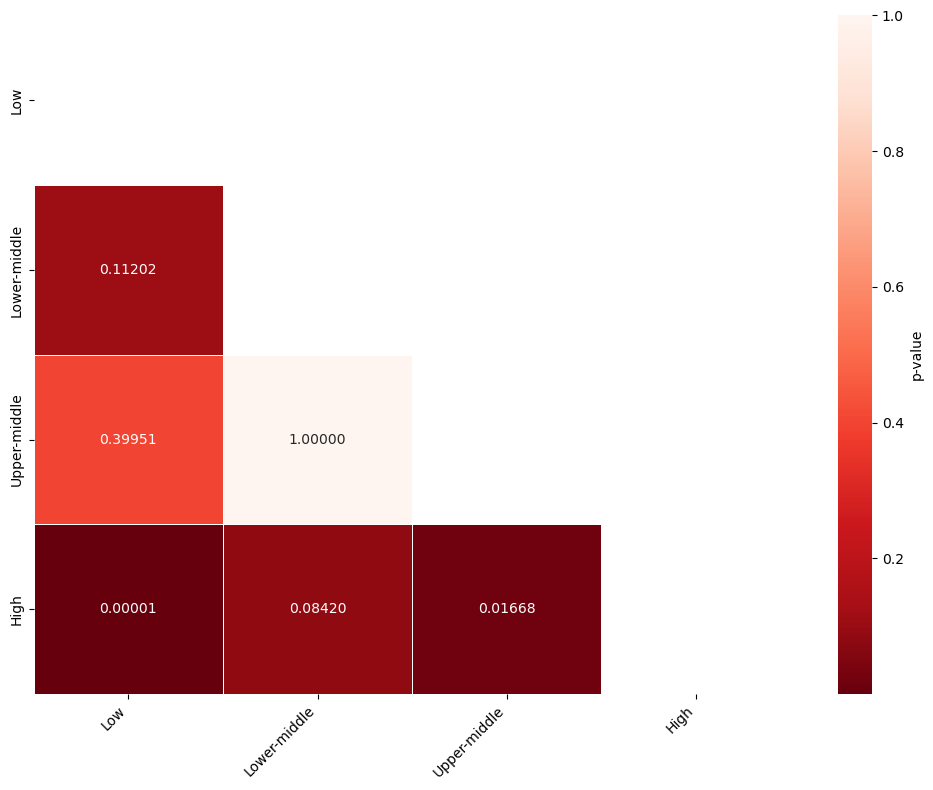

In [166]:
# Побудуємо теплову карту для візуалізації результатів тесту Данна між категоріями багатства країни
mask = np.triu(np.ones_like(dunn_results, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(dunn_results, annot=True, cmap='Reds_r', fmt=".5f", linewidths=0.5, mask=mask, cbar_kws={'label': 'p-value'})
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


## Висновок:
<p style="font-family: Arial, sans-serif; font-size: 20px;">У результаті перевірки розподілу за допомогою критерію Шапіро-Уілка було встановлено, що дані в усіх групах не відповідають нормальному розподілу. У зв’язку з цим для подальшого аналізу було застосовано непараметричний критерій Краскела-Уолліса. Результати тесту (H = 23.56, p < 0.001) свідчать про наявність статистично значущих відмінностей у рівнях викидів CO2 між групами країн, згрупованих за рівнем ВВП на душу населення. Для визначення того, між якими саме групами існують відмíнності, було проведено аналіз за допомогою тесту Данна. Результати показали, що статистично значущі відмíнності спостережуються між групами з низьким та високим рівнем доходу, а також між групами з високим та середньо-високим рівнем доходу. Водночас між іншими групами статистично значущих відмíнностей не виявлено.</p>

<h2>Виконав студент групи ІП-45 <br> Буряк Володимир</h2>